# SIC Mean/Std Sweep Diagnostics

This notebook tests whether the sea-ice concentration rank histogram changes substantially if the saved physical ensemble is interpreted as coming from the current normalized model output and then denormalized with alternative concentration `mean/std` values.

The saved `samples/**/*.npz` tensors from `synthetic_eval.cli --save-tensors` are already in physical units. For each candidate pair this notebook does:

```python
sic_norm = (saved_sic - current_sic_mean) / current_sic_std
sic_candidate = sic_norm * candidate_sic_std + candidate_sic_mean
sic_candidate = clip(sic_candidate, 0, 1)
sic_candidate[:, invalid_padding_mask] = 0
```

Computations are optimized so each archive is loaded once per analysis cell while all candidate `mean/std` pairs are evaluated together.


In [1]:
from __future__ import annotations

import json
import math
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

try:
    import pandas as pd
except ImportError:
    pd = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 1. Locate The Synthetic Eval Run

By default this follows `experiments_synthetic_eval_results_viewer.ipynb`: it reads `SYNTH_EVAL_OUT`, otherwise uses `<DATA_ROOT>/synthetic_eval_swath_30days_x32_r4_saved`, otherwise falls back to the newest `synthetic_eval*` directory under `DATA_ROOT`.


In [2]:
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/mnt/sciml/a.sadreev/sea_ice_data"))
OUT_DIR = Path(
    os.environ.get(
        "SYNTH_EVAL_OUT",
        DATA_ROOT / "synthetic_eval_swath_30days_x32_r4_saved",
    )
)

if not OUT_DIR.exists():
    candidates = sorted(DATA_ROOT.glob("synthetic_eval*"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No synthetic_eval output directories found under {DATA_ROOT}")
    print(f"Configured OUT_DIR does not exist: {OUT_DIR}")
    OUT_DIR = candidates[0]
    print(f"Using latest synthetic_eval directory instead: {OUT_DIR}")

PLOTS_DIR = OUT_DIR / "plots"
ARRAYS_DIR = OUT_DIR / "arrays"
SAMPLES_DIR = OUT_DIR / "samples"
SWEEP_PLOTS_DIR = PLOTS_DIR / "sic_mean_std_sweep"
SWEEP_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

metadata_path = OUT_DIR / "metadata.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

tensor_paths = sorted(SAMPLES_DIR.glob("**/*.npz"))
if not tensor_paths:
    raise FileNotFoundError(f"No saved tensor archives found under {SAMPLES_DIR}; rerun eval with --save-tensors")

print("OUT_DIR    =", OUT_DIR)
print("PLOTS_DIR  =", PLOTS_DIR)
print("ARRAYS_DIR =", ARRAYS_DIR)
print("SAMPLES_DIR=", SAMPLES_DIR)
print("n archives =", len(tensor_paths))
print("eval_region=", metadata.get("eval_region", "unobserved"))
print("rank_stride=", metadata.get("rank_stride", 4))
for path in tensor_paths[:8]:
    print(" ", path.relative_to(OUT_DIR))
if len(tensor_paths) > 8:
    print(f"  ... {len(tensor_paths) - 8} more")


OUT_DIR    = /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved
PLOTS_DIR  = /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/plots
ARRAYS_DIR = /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/arrays
SAMPLES_DIR= /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/samples
n archives = 120
eval_region= unobserved
rank_stride= 8
  samples/swath_r00_d0p05_n0/case0000_idx0_ocean+atmosphere_24_2022-01-01_processed000.npy.npz
  samples/swath_r00_d0p05_n0/case0001_idx24_ocean+atmosphere_24_2022-01-02_processed000.npy.npz
  samples/swath_r00_d0p05_n0/case0002_idx48_ocean+atmosphere_24_2022-01-03_processed000.npy.npz
  samples/swath_r00_d0p05_n0/case0003_idx72_ocean+atmosphere_24_2022-01-04_processed000.npy.npz
  samples/swath_r00_d0p05_n0/case0004_idx96_ocean+atmosphere_24_2022-01-05_processed000.npy.npz
  samples/swath_r00_d0p05_n0/case0005_idx120_ocean+atmosphere_24_2022-01-06_processed000.npy

## 2. Current Stats And Candidate Mean/Std Grid

Current stats are loaded from `metadata["stats_json"]`. Change only `SIC_MEAN_STD_GRID` in this cell to test another set of concentration denormalization parameters.


In [3]:
def load_channel_stats(metadata):
    stats_json = metadata.get("stats_json")
    if not stats_json:
        raise KeyError("metadata does not contain stats_json")
    stats_path = Path(stats_json)
    if not stats_path.exists():
        raise FileNotFoundError(stats_path)
    with open(stats_path) as f:
        stats = json.load(f)
    return stats_path, np.asarray(stats["mean"], dtype=np.float64), np.asarray(stats["std"], dtype=np.float64)


stats_path, CURRENT_MEAN, CURRENT_STD = load_channel_stats(metadata)
CURRENT_SIC_MEAN = float(CURRENT_MEAN[0])
CURRENT_SIC_STD = float(CURRENT_STD[0])

print("Current stats_json:", stats_path)
print("Current channel mean:", CURRENT_MEAN)
print("Current channel std: ", CURRENT_STD)
print("Current SIC mean/std:", CURRENT_SIC_MEAN, CURRENT_SIC_STD)

# ============================================================
# CHANGE CANDIDATE SIC MEAN/STD HERE
# Each entry is: (label, candidate_sic_mean, candidate_sic_std)
# ============================================================
SIC_MEAN_STD_GRID = [
    ("current", CURRENT_SIC_MEAN, CURRENT_SIC_STD),

    ("mean -0.100", CURRENT_SIC_MEAN - 0.100, CURRENT_SIC_STD),
    ("mean -0.050", CURRENT_SIC_MEAN - 0.050, CURRENT_SIC_STD),
    ("mean -0.025", CURRENT_SIC_MEAN - 0.025, CURRENT_SIC_STD),
    ("mean +0.025", CURRENT_SIC_MEAN + 0.025, CURRENT_SIC_STD),
    ("mean +0.050", CURRENT_SIC_MEAN + 0.050, CURRENT_SIC_STD),
    ("mean +0.100", CURRENT_SIC_MEAN + 0.100, CURRENT_SIC_STD),

    ("std x0.75", CURRENT_SIC_MEAN, CURRENT_SIC_STD * 0.75),
    ("std x0.90", CURRENT_SIC_MEAN, CURRENT_SIC_STD * 0.90),
    ("std x1.10", CURRENT_SIC_MEAN, CURRENT_SIC_STD * 1.10),
    ("std x1.25", CURRENT_SIC_MEAN, CURRENT_SIC_STD * 1.25),

    ("mean -0.025, std x0.90", CURRENT_SIC_MEAN - 0.025, CURRENT_SIC_STD * 0.90),
    ("mean +0.025, std x1.10", CURRENT_SIC_MEAN + 0.025, CURRENT_SIC_STD * 1.10),
]

CANDIDATE_LABELS = [str(x[0]) for x in SIC_MEAN_STD_GRID]
CANDIDATE_MEANS = np.asarray([float(x[1]) for x in SIC_MEAN_STD_GRID], dtype=np.float64)
CANDIDATE_STDS = np.asarray([float(x[2]) for x in SIC_MEAN_STD_GRID], dtype=np.float64)

if np.any(CANDIDATE_STDS <= 0):
    raise ValueError("All candidate std values must be positive")

candidate_table = [
    {"label": label, "sic_mean": mean, "sic_std": std}
    for label, mean, std in zip(CANDIDATE_LABELS, CANDIDATE_MEANS, CANDIDATE_STDS)
]
if pd is not None:
    display(pd.DataFrame(candidate_table))
else:
    display(candidate_table)


Current stats_json: /mnt/sciml/a.sadreev/sea_ice_data/train/stats.json
Current channel mean: [0.1158 0.1153]
Current channel std:  [0.3008 0.3501]
Current SIC mean/std: 0.1158 0.3008


[{'label': 'current',
  'sic_mean': np.float64(0.1158),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean -0.100',
  'sic_mean': np.float64(0.015799999999999995),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean -0.050',
  'sic_mean': np.float64(0.0658),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean -0.025',
  'sic_mean': np.float64(0.09079999999999999),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean +0.025',
  'sic_mean': np.float64(0.1408),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean +0.050',
  'sic_mean': np.float64(0.1658),
  'sic_std': np.float64(0.3008)},
 {'label': 'mean +0.100',
  'sic_mean': np.float64(0.2158),
  'sic_std': np.float64(0.3008)},
 {'label': 'std x0.75',
  'sic_mean': np.float64(0.1158),
  'sic_std': np.float64(0.22560000000000002)},
 {'label': 'std x0.90',
  'sic_mean': np.float64(0.1158),
  'sic_std': np.float64(0.27072)},
 {'label': 'std x1.10',
  'sic_mean': np.float64(0.1158),
  'sic_std': np.float64(0.33088000000000006)},
 {'label': 'std 

## 3. Helpers

Invalid padding mask is forced to zero after every candidate transform. Evaluation masks also exclude invalid padding cells.


In [4]:
RANK_STRIDE = int(metadata.get("rank_stride", 4) or 4)
EVAL_REGION = metadata.get("eval_region", "unobserved")
CHANNEL = 0


def scalar_int(z, key, default=0):
    if key not in z.files:
        return default
    return int(np.asarray(z[key]).item())


def safe_name(text):
    return (
        str(text)
        .replace("+", "plus")
        .replace("-", "minus")
        .replace(".", "p")
        .replace(", ", "__")
        .replace(" ", "_")
        .replace("=", "")
    )


def load_valid_mask(shape_hw):
    candidates = []
    if metadata.get("mask_path"):
        candidates.append(Path(metadata["mask_path"]))
    candidates.extend([
        DATA_ROOT / "mask_padding.npy",
        Path("/Users/amir/sciml/sea_ice_data/mask_padding.npy"),
        Path("/mnt/sciml/a.sadreev/sea_ice_data/mask_padding.npy"),
    ])
    for path in candidates:
        if path.exists():
            valid = np.load(path).astype(bool)
            if valid.ndim == 3:
                valid = valid[0]
            if tuple(valid.shape) == tuple(shape_hw):
                return valid
    return np.ones(shape_hw, dtype=bool)


def make_eval_mask(observed_mask, valid_mask, eval_region=EVAL_REGION):
    observed = np.asarray(observed_mask, dtype=bool)
    valid = np.asarray(valid_mask, dtype=bool)
    if eval_region == "all":
        return valid
    if eval_region == "observed":
        return valid & observed
    if eval_region == "unobserved":
        return valid & ~observed
    raise ValueError(f"Unknown eval_region: {eval_region}")


def apply_all_candidate_stats(ensemble_sic_physical, valid_mask):
    # Return shape (K, M, H, W), where K is number of candidate mean/std pairs.
    ens_norm = (ensemble_sic_physical.astype(np.float64) - CURRENT_SIC_MEAN) / CURRENT_SIC_STD
    corrected = ens_norm[None, ...] * CANDIDATE_STDS[:, None, None, None] + CANDIDATE_MEANS[:, None, None, None]
    corrected = np.clip(corrected, 0.0, 1.0)

    # Invalid/padding cells must always be zero.
    corrected[:, :, ~valid_mask] = 0.0
    return corrected


def rank_scores_from_counts(counts):
    counts = np.asarray(counts, dtype=np.float64)
    total = counts.sum()
    if total <= 0:
        return {
            "total_ranks": 0,
            "l1_flat": np.nan,
            "edge_ratio_vs_flat": np.nan,
            "center_ratio_vs_flat": np.nan,
            "right_minus_left_edges_in_flat_units": np.nan,
            "chi2_like_not_independent": np.nan,
        }
    probs = counts / total
    expected = 1.0 / len(probs)
    center = probs[len(probs) // 3 : 2 * len(probs) // 3]
    return {
        "total_ranks": int(total),
        "l1_flat": float(np.abs(probs - expected).sum()),
        "edge_ratio_vs_flat": float((probs[0] + probs[-1]) / (2 * expected)),
        "center_ratio_vs_flat": float(center.mean() / expected),
        "right_minus_left_edges_in_flat_units": float((probs[-1] - probs[0]) / expected),
        "chi2_like_not_independent": float(((counts - total * expected) ** 2 / max(total * expected, 1.0)).sum()),
    }


with np.load(tensor_paths[0], allow_pickle=False) as z0:
    truth0 = z0["truth"][CHANNEL]
    valid_mask0 = load_valid_mask(truth0.shape)
    print("sample truth shape:", truth0.shape)
    print("valid fraction:", float(valid_mask0.mean()))
    print("eval region:", EVAL_REGION)
    print("rank stride:", RANK_STRIDE)


sample truth shape: (320, 256)
valid fraction: 0.85418701171875
eval region: unobserved
rank stride: 8


## 4. Pixel Value Distributions

This cell builds the pixel-value distribution for every candidate `mean/std`. It loads each archive once and evaluates all candidates together. Invalid padding cells are zeroed before sampling; distributions are drawn over `EVAL_REGION` only.


loaded 40 archives in 18.6 sec
mean raw saved outside [0, 1] fraction: 0.0
saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/plots/sic_mean_std_sweep/sic_pixel_distributions_by_mean_std.png


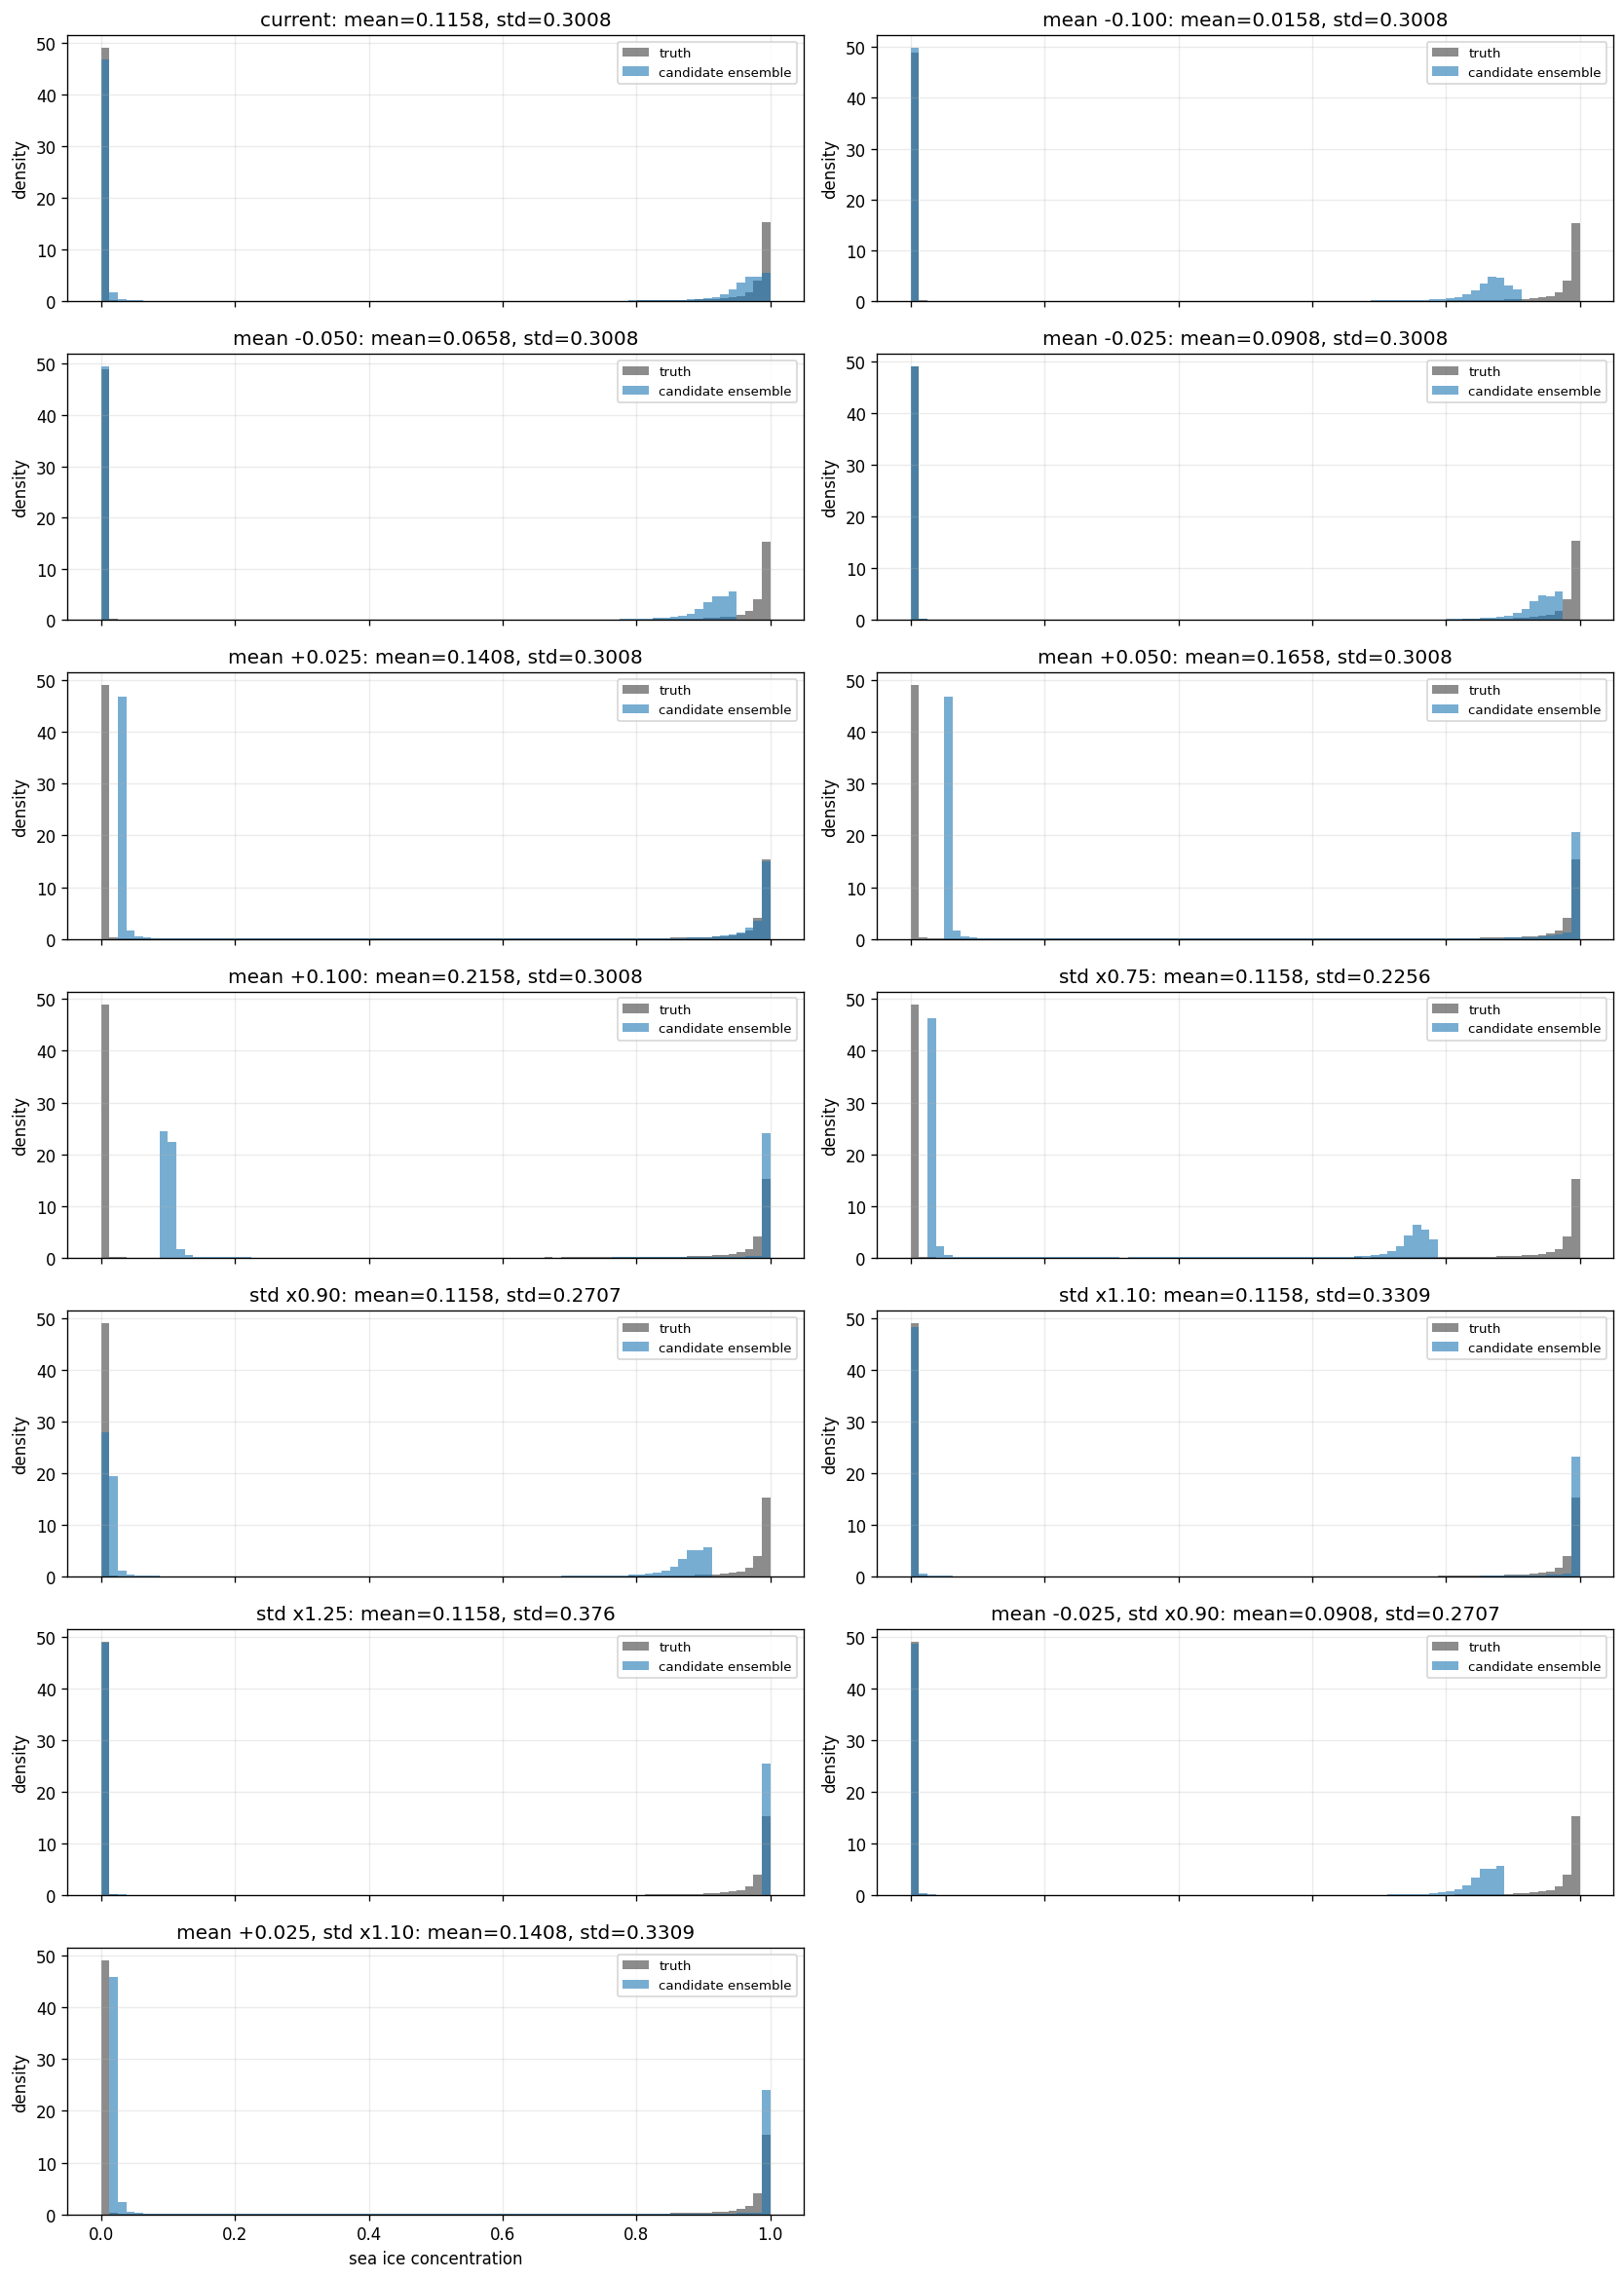

In [5]:
MAX_ARCHIVES_FOR_DISTRIBUTION = min(len(tensor_paths), 40)
MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE = 25000
DISTRIBUTION_SEED = 123

rng = np.random.default_rng(DISTRIBUTION_SEED)
paths_for_dist = tensor_paths[:MAX_ARCHIVES_FOR_DISTRIBUTION]

candidate_values = [[] for _ in CANDIDATE_LABELS]
truth_values = []
raw_saved_values = []
raw_saved_outside = []

t0 = time.perf_counter()
for archive_i, path in enumerate(paths_for_dist):
    with np.load(path, allow_pickle=False) as z:
        ensemble_sic = z["ensemble"][:, CHANNEL]
        truth_sic = z["truth"][CHANNEL].astype(np.float64)
        observed_mask = z["mask"]

    valid_mask = load_valid_mask(truth_sic.shape)
    eval_mask = make_eval_mask(observed_mask, valid_mask, EVAL_REGION)

    corrected = apply_all_candidate_stats(ensemble_sic, valid_mask)
    raw_saved = ensemble_sic.astype(np.float64).copy()
    raw_saved[:, ~valid_mask] = 0.0

    raw_flat = raw_saved[:, eval_mask].reshape(-1)
    raw_saved_outside.append(float(np.mean((raw_flat < 0.0) | (raw_flat > 1.0))) if raw_flat.size else np.nan)
    if raw_flat.size > MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE:
        raw_flat = rng.choice(raw_flat, size=MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE, replace=False)
    raw_saved_values.append(raw_flat)

    truth_flat = truth_sic[eval_mask].reshape(-1)
    if truth_flat.size > MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE:
        truth_flat = rng.choice(truth_flat, size=MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE, replace=False)
    truth_values.append(truth_flat)

    flat_candidates = corrected[:, :, eval_mask].reshape(len(CANDIDATE_LABELS), -1)
    for k in range(len(CANDIDATE_LABELS)):
        vals = flat_candidates[k]
        if vals.size > MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE:
            vals = rng.choice(vals, size=MAX_PIXELS_PER_ARCHIVE_PER_CANDIDATE, replace=False)
        candidate_values[k].append(vals)

truth_values = np.concatenate(truth_values) if truth_values else np.array([])
raw_saved_values = np.concatenate(raw_saved_values) if raw_saved_values else np.array([])
candidate_values = [np.concatenate(vals) if vals else np.array([]) for vals in candidate_values]

print(f"loaded {len(paths_for_dist)} archives in {time.perf_counter() - t0:.1f} sec")
print("mean raw saved outside [0, 1] fraction:", float(np.nanmean(raw_saved_outside)))

ncols = 2
nrows = int(math.ceil(len(CANDIDATE_LABELS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 2.8 * nrows), squeeze=False, sharex=True)
bins = np.linspace(0.0, 1.0, 81)

for ax, label, mean, std, vals in zip(axes.ravel(), CANDIDATE_LABELS, CANDIDATE_MEANS, CANDIDATE_STDS, candidate_values):
    ax.hist(truth_values, bins=bins, density=True, alpha=0.45, color="black", label="truth")
    ax.hist(vals, bins=bins, density=True, alpha=0.60, color="tab:blue", label="candidate ensemble")
    ax.set_title(f"{label}: mean={mean:.4g}, std={std:.4g}")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

for ax in axes.ravel()[len(CANDIDATE_LABELS):]:
    ax.axis("off")
axes[-1, 0].set_xlabel("sea ice concentration")
if ncols > 1:
    axes[-1, 1].set_xlabel("sea ice concentration")
plt.tight_layout()

out_path = SWEEP_PLOTS_DIR / "sic_pixel_distributions_by_mean_std.png"
fig.savefig(out_path, dpi=160)
print("saved:", out_path)
plt.show()


stats_json: /mnt/sciml/a.sadreev/sea_ice_data/train/stats.json
current SIC mean/std: 0.1158 0.3008
manual  SIC mean/std: 0.105 0.31
eval region: unobserved
archives used: 40
truth values: 1200000
saved ensemble values: 1200000
manual ensemble values: 1200000
manual exact zero fraction: 0.58975
manual exact one fraction:  0.08315


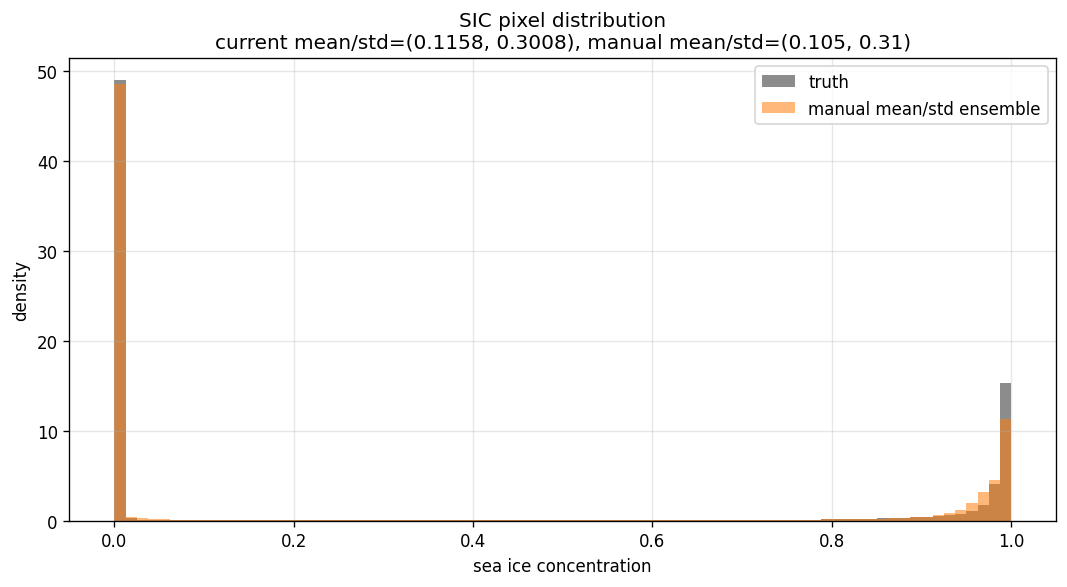

In [23]:
# One-cell SIC pixel distribution for manually chosen mean/std.
# Assumes previous viewer notebook variables exist:
# OUT_DIR, PLOTS_DIR, SAMPLES_DIR, metadata, tensor_paths

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ================================
# CHANGE THESE TWO VALUES MANUALLY
# ================================
MANUAL_SIC_MEAN = 0.105
MANUAL_SIC_STD = 0.31

MAX_ARCHIVES = 40
MAX_PIXELS_PER_ARCHIVE = 30000
EVAL_REGION = metadata.get("eval_region", "unobserved")
CHANNEL = 0
RNG_SEED = 123


def load_current_sic_stats(metadata):
    stats_path = Path(metadata["stats_json"])
    with open(stats_path) as f:
        stats = json.load(f)
    mean = np.asarray(stats["mean"], dtype=np.float64)
    std = np.asarray(stats["std"], dtype=np.float64)
    return stats_path, float(mean[0]), float(std[0])


def load_valid_mask(shape_hw):
    candidates = []
    if metadata.get("mask_path"):
        candidates.append(Path(metadata["mask_path"]))
    candidates.extend([
        Path("/Users/amir/sciml/sea_ice_data/mask_padding.npy"),
        Path("/mnt/sciml/a.sadreev/sea_ice_data/mask_padding.npy"),
    ])

    for path in candidates:
        if path.exists():
            valid = np.load(path).astype(bool)
            if valid.ndim == 3:
                valid = valid[0]
            if valid.shape == shape_hw:
                return valid

    return np.ones(shape_hw, dtype=bool)


def make_eval_mask(observed_mask, valid_mask, eval_region):
    observed = np.asarray(observed_mask, dtype=bool)
    valid = np.asarray(valid_mask, dtype=bool)

    if eval_region == "all":
        return valid
    if eval_region == "observed":
        return valid & observed
    if eval_region == "unobserved":
        return valid & ~observed

    raise ValueError(f"unknown eval_region={eval_region}")


def apply_manual_sic_stats(ensemble_sic_physical, valid_mask):
    # Saved ensemble is already physical:
    # saved = norm * CURRENT_SIC_STD + CURRENT_SIC_MEAN
    # so reconstruct norm, then denormalize with manual stats.
    ens_norm = (ensemble_sic_physical.astype(np.float64) - CURRENT_SIC_MEAN) / CURRENT_SIC_STD
    corrected = ens_norm * MANUAL_SIC_STD + MANUAL_SIC_MEAN
    corrected = np.clip(corrected, 0.0, 1.0)

    # Padding/invalid mask must always be zero.
    corrected[:, ~valid_mask] = 0.0
    return corrected


stats_path, CURRENT_SIC_MEAN, CURRENT_SIC_STD = load_current_sic_stats(metadata)

print("stats_json:", stats_path)
print("current SIC mean/std:", CURRENT_SIC_MEAN, CURRENT_SIC_STD)
print("manual  SIC mean/std:", MANUAL_SIC_MEAN, MANUAL_SIC_STD)
print("eval region:", EVAL_REGION)

rng = np.random.default_rng(RNG_SEED)

truth_values = []
saved_values = []
manual_values = []

paths = tensor_paths[: min(len(tensor_paths), MAX_ARCHIVES)]

for path in paths:
    with np.load(path, allow_pickle=False) as z:
        ensemble_sic = z["ensemble"][:, CHANNEL]
        truth_sic = z["truth"][CHANNEL].astype(np.float64)
        observed_mask = z["mask"]

    valid_mask = load_valid_mask(truth_sic.shape)
    eval_mask = make_eval_mask(observed_mask, valid_mask, EVAL_REGION)

    saved = ensemble_sic.astype(np.float64).copy()
    saved[:, ~valid_mask] = 0.0

    manual = apply_manual_sic_stats(ensemble_sic, valid_mask)

    truth_flat = truth_sic[eval_mask].reshape(-1)
    saved_flat = saved[:, eval_mask].reshape(-1)
    manual_flat = manual[:, eval_mask].reshape(-1)

    if truth_flat.size > MAX_PIXELS_PER_ARCHIVE:
        truth_flat = rng.choice(truth_flat, size=MAX_PIXELS_PER_ARCHIVE, replace=False)
    if saved_flat.size > MAX_PIXELS_PER_ARCHIVE:
        saved_flat = rng.choice(saved_flat, size=MAX_PIXELS_PER_ARCHIVE, replace=False)
    if manual_flat.size > MAX_PIXELS_PER_ARCHIVE:
        manual_flat = rng.choice(manual_flat, size=MAX_PIXELS_PER_ARCHIVE, replace=False)

    truth_values.append(truth_flat)
    saved_values.append(saved_flat)
    manual_values.append(manual_flat)

truth_values = np.concatenate(truth_values)
saved_values = np.concatenate(saved_values)
manual_values = np.concatenate(manual_values)

print("archives used:", len(paths))
print("truth values:", truth_values.size)
print("saved ensemble values:", saved_values.size)
print("manual ensemble values:", manual_values.size)
print("manual exact zero fraction:", float(np.mean(manual_values == 0.0)))
print("manual exact one fraction: ", float(np.mean(manual_values == 1.0)))

bins = np.linspace(0.0, 1.0, 81)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(truth_values, bins=bins, density=True, alpha=0.45, color="black", label="truth")
#ax.hist(saved_values, bins=bins, density=True, alpha=0.45, color="tab:blue", label="saved ensemble")
ax.hist(manual_values, bins=bins, density=True, alpha=0.55, color="tab:orange", label="manual mean/std ensemble")

ax.set_title(
    "SIC pixel distribution\n"
    f"current mean/std=({CURRENT_SIC_MEAN:.4g}, {CURRENT_SIC_STD:.4g}), "
    f"manual mean/std=({MANUAL_SIC_MEAN:.4g}, {MANUAL_SIC_STD:.4g})"
)
ax.set_xlabel("sea ice concentration")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

stats_json: /mnt/sciml/a.sadreev/sea_ice_data/train/stats.json
current SIC mean/std: 0.1158 0.3008
manual  SIC mean/std: 0.105 0.31
eval region: unobserved
rank stride: 8
archives used: 120
saved scores: {'total_ranks': 128380, 'l1_flat': 0.37972968507319654, 'edge_ratio_vs_flat': 1.8398309705561615, 'center_ratio_vs_flat': 0.8562548683595577, 'right_minus_left_edges_in_flat_units': 0.6855507088331516, 'chi2_like_not_independent': 23892.55547593083}
manual scores: {'total_ranks': 128380, 'l1_flat': 0.03455461296246466, 'edge_ratio_vs_flat': 0.9296190995482162, 'center_ratio_vs_flat': 0.9890792958404734, 'right_minus_left_edges_in_flat_units': -0.1421483097055617, 'chi2_like_not_independent': 283.2943760710391}


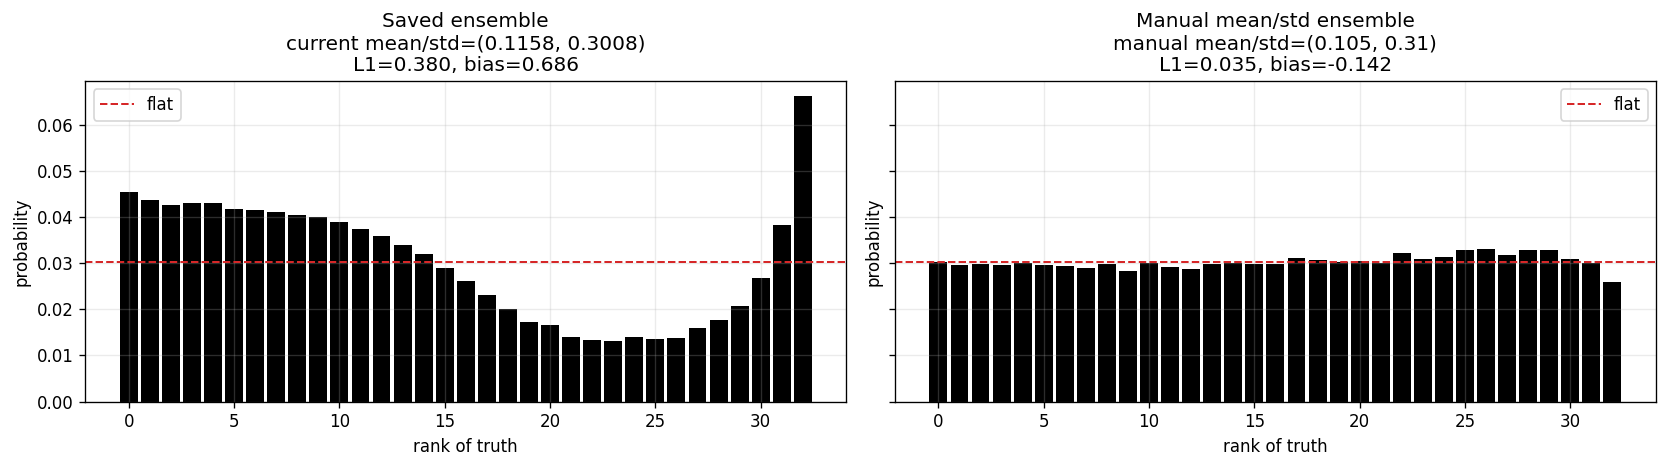

In [22]:
# One-cell SIC rank histogram for manually chosen mean/std.
# Assumes previous viewer notebook variables exist:
# metadata, tensor_paths

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ================================
# CHANGE THESE TWO VALUES MANUALLY
# ================================
MANUAL_SIC_MEAN = 0.105
MANUAL_SIC_STD = 0.31

RANK_STRIDE = int(metadata.get("rank_stride", 4) or 4)
EVAL_REGION = metadata.get("eval_region", "unobserved")
CHANNEL = 0
MAX_ARCHIVES = None  # set e.g. 20 for quick test


def load_current_sic_stats(metadata):
    stats_path = Path(metadata["stats_json"])
    with open(stats_path) as f:
        stats = json.load(f)
    mean = np.asarray(stats["mean"], dtype=np.float64)
    std = np.asarray(stats["std"], dtype=np.float64)
    return stats_path, float(mean[0]), float(std[0])


def load_valid_mask(shape_hw):
    candidates = []
    if metadata.get("mask_path"):
        candidates.append(Path(metadata["mask_path"]))
    candidates.extend([
        Path("/Users/amir/sciml/sea_ice_data/mask_padding.npy"),
        Path("/mnt/sciml/a.sadreev/sea_ice_data/mask_padding.npy"),
    ])

    for path in candidates:
        if path.exists():
            valid = np.load(path).astype(bool)
            if valid.ndim == 3:
                valid = valid[0]
            if valid.shape == shape_hw:
                return valid

    return np.ones(shape_hw, dtype=bool)


def make_eval_mask(observed_mask, valid_mask, eval_region):
    observed = np.asarray(observed_mask, dtype=bool)
    valid = np.asarray(valid_mask, dtype=bool)

    if eval_region == "all":
        return valid
    if eval_region == "observed":
        return valid & observed
    if eval_region == "unobserved":
        return valid & ~observed

    raise ValueError(f"unknown eval_region={eval_region}")


def apply_manual_sic_stats(ensemble_sic_physical, valid_mask):
    # Saved ensemble is already physical:
    # saved = norm * CURRENT_SIC_STD + CURRENT_SIC_MEAN
    # reconstruct norm, then denormalize with manual stats.
    ens_norm = (ensemble_sic_physical.astype(np.float64) - CURRENT_SIC_MEAN) / CURRENT_SIC_STD
    corrected = ens_norm * MANUAL_SIC_STD + MANUAL_SIC_MEAN
    corrected = np.clip(corrected, 0.0, 1.0)

    # Padding/invalid mask must always be zero.
    corrected[:, ~valid_mask] = 0.0
    return corrected


def rank_histogram_np(ensemble, truth, seed=0, weights_mask=None):
    ens = np.asarray(ensemble, dtype=np.float64)
    y = np.asarray(truth, dtype=np.float64)

    rng = np.random.default_rng(seed)
    less = np.sum(ens < y[None, ...], axis=0)
    ties = np.sum(ens == y[None, ...], axis=0)
    ranks = less + rng.integers(0, ties + 1)

    if weights_mask is not None:
        ranks = ranks[np.asarray(weights_mask, dtype=bool)]

    return np.bincount(
        ranks.reshape(-1).astype(np.int64),
        minlength=ens.shape[0] + 1,
    )


def rank_scores(counts):
    counts = np.asarray(counts, dtype=np.float64)
    total = counts.sum()
    probs = counts / max(total, 1.0)
    expected = 1.0 / len(probs)
    center = probs[len(probs)//3 : 2*len(probs)//3]

    return {
        "total_ranks": int(total),
        "l1_flat": float(np.abs(probs - expected).sum()),
        "edge_ratio_vs_flat": float((probs[0] + probs[-1]) / (2 * expected)),
        "center_ratio_vs_flat": float(center.mean() / expected),
        "right_minus_left_edges_in_flat_units": float((probs[-1] - probs[0]) / expected),
        "chi2_like_not_independent": float(((counts - total * expected) ** 2 / max(total * expected, 1.0)).sum()),
    }


stats_path, CURRENT_SIC_MEAN, CURRENT_SIC_STD = load_current_sic_stats(metadata)

print("stats_json:", stats_path)
print("current SIC mean/std:", CURRENT_SIC_MEAN, CURRENT_SIC_STD)
print("manual  SIC mean/std:", MANUAL_SIC_MEAN, MANUAL_SIC_STD)
print("eval region:", EVAL_REGION)
print("rank stride:", RANK_STRIDE)

paths = tensor_paths if MAX_ARCHIVES is None else tensor_paths[:MAX_ARCHIVES]

counts_saved_total = None
counts_manual_total = None

for archive_i, path in enumerate(paths):
    with np.load(path, allow_pickle=False) as z:
        ensemble_sic = z["ensemble"][:, CHANNEL]
        truth_sic = z["truth"][CHANNEL].astype(np.float64)
        observed_mask = z["mask"]
        combo_seed = int(np.asarray(z["combo_seed"]).item()) if "combo_seed" in z.files else archive_i

    valid_mask = load_valid_mask(truth_sic.shape)
    eval_mask = make_eval_mask(observed_mask, valid_mask, EVAL_REGION)

    saved = ensemble_sic.astype(np.float64).copy()
    saved[:, ~valid_mask] = 0.0

    manual = apply_manual_sic_stats(ensemble_sic, valid_mask)

    rank_mask = eval_mask[::RANK_STRIDE, ::RANK_STRIDE]

    counts_saved = rank_histogram_np(
        saved[:, ::RANK_STRIDE, ::RANK_STRIDE],
        truth_sic[::RANK_STRIDE, ::RANK_STRIDE],
        seed=combo_seed + CHANNEL,
        weights_mask=rank_mask,
    )

    counts_manual = rank_histogram_np(
        manual[:, ::RANK_STRIDE, ::RANK_STRIDE],
        truth_sic[::RANK_STRIDE, ::RANK_STRIDE],
        seed=combo_seed + CHANNEL,
        weights_mask=rank_mask,
    )

    counts_saved_total = counts_saved if counts_saved_total is None else counts_saved_total + counts_saved
    counts_manual_total = counts_manual if counts_manual_total is None else counts_manual_total + counts_manual


saved_scores = rank_scores(counts_saved_total)
manual_scores = rank_scores(counts_manual_total)

print("archives used:", len(paths))
print("saved scores:", saved_scores)
print("manual scores:", manual_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, title, counts, scores in [
    (
        axes[0],
        f"Saved ensemble\ncurrent mean/std=({CURRENT_SIC_MEAN:.4g}, {CURRENT_SIC_STD:.4g})",
        counts_saved_total,
        saved_scores,
    ),
    (
        axes[1],
        f"Manual mean/std ensemble\nmanual mean/std=({MANUAL_SIC_MEAN:.4g}, {MANUAL_SIC_STD:.4g})",
        counts_manual_total,
        manual_scores,
    ),
]:
    probs = counts / max(1.0, counts.sum())
    expected = 1.0 / len(probs)

    ax.bar(np.arange(len(probs)), probs, color="black", width=0.85)
    ax.axhline(expected, color="tab:red", linestyle="--", linewidth=1.2, label="flat")
    ax.set_title(
        f"{title}\n"
        f"L1={scores['l1_flat']:.3f}, "
        f"bias={scores['right_minus_left_edges_in_flat_units']:.3f}"
    )
    ax.set_xlabel("rank of truth")
    ax.set_ylabel("probability")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Rank Histograms

This cell computes rank histograms for all candidate `mean/std` pairs. It is optimized to load each archive once and compute all candidate rank arrays in one vectorized block per archive.


rank histograms computed for 120 archives in 24.9 sec


[{'label': 'current',
  'candidate_mean': 0.1158,
  'candidate_std': 0.3008,
  'total_ranks': 128380,
  'l1_flat': 0.37972968507319654,
  'edge_ratio_vs_flat': 1.8398309705561615,
  'center_ratio_vs_flat': 0.8562548683595577,
  'right_minus_left_edges_in_flat_units': 0.6855507088331516,
  'chi2_like_not_independent': 23892.55547593083,
  'rmse_mean': 0.08765177916917648,
  'bias_mean': -0.005334575422702409,
  'mae_mean': 0.031097233348688004},
 {'label': 'std x1.10',
  'candidate_mean': 0.1158,
  'candidate_std': 0.33088000000000006,
  'total_ranks': 128380,
  'l1_flat': 0.46064005060733526,
  'edge_ratio_vs_flat': 3.692899984421249,
  'center_ratio_vs_flat': 0.7600015578750585,
  'right_minus_left_edges_in_flat_units': -6.743690606013398,
  'chi2_like_not_independent': 157529.82587630465,
  'rmse_mean': 0.08802014793767142,
  'bias_mean': 0.006426572197483186,
  'mae_mean': 0.026692794849682837},
 {'label': 'mean -0.025',
  'candidate_mean': 0.09079999999999999,
  'candidate_std': 0.

saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/plots/sic_mean_std_sweep/sic_rank_histograms_by_mean_std.png


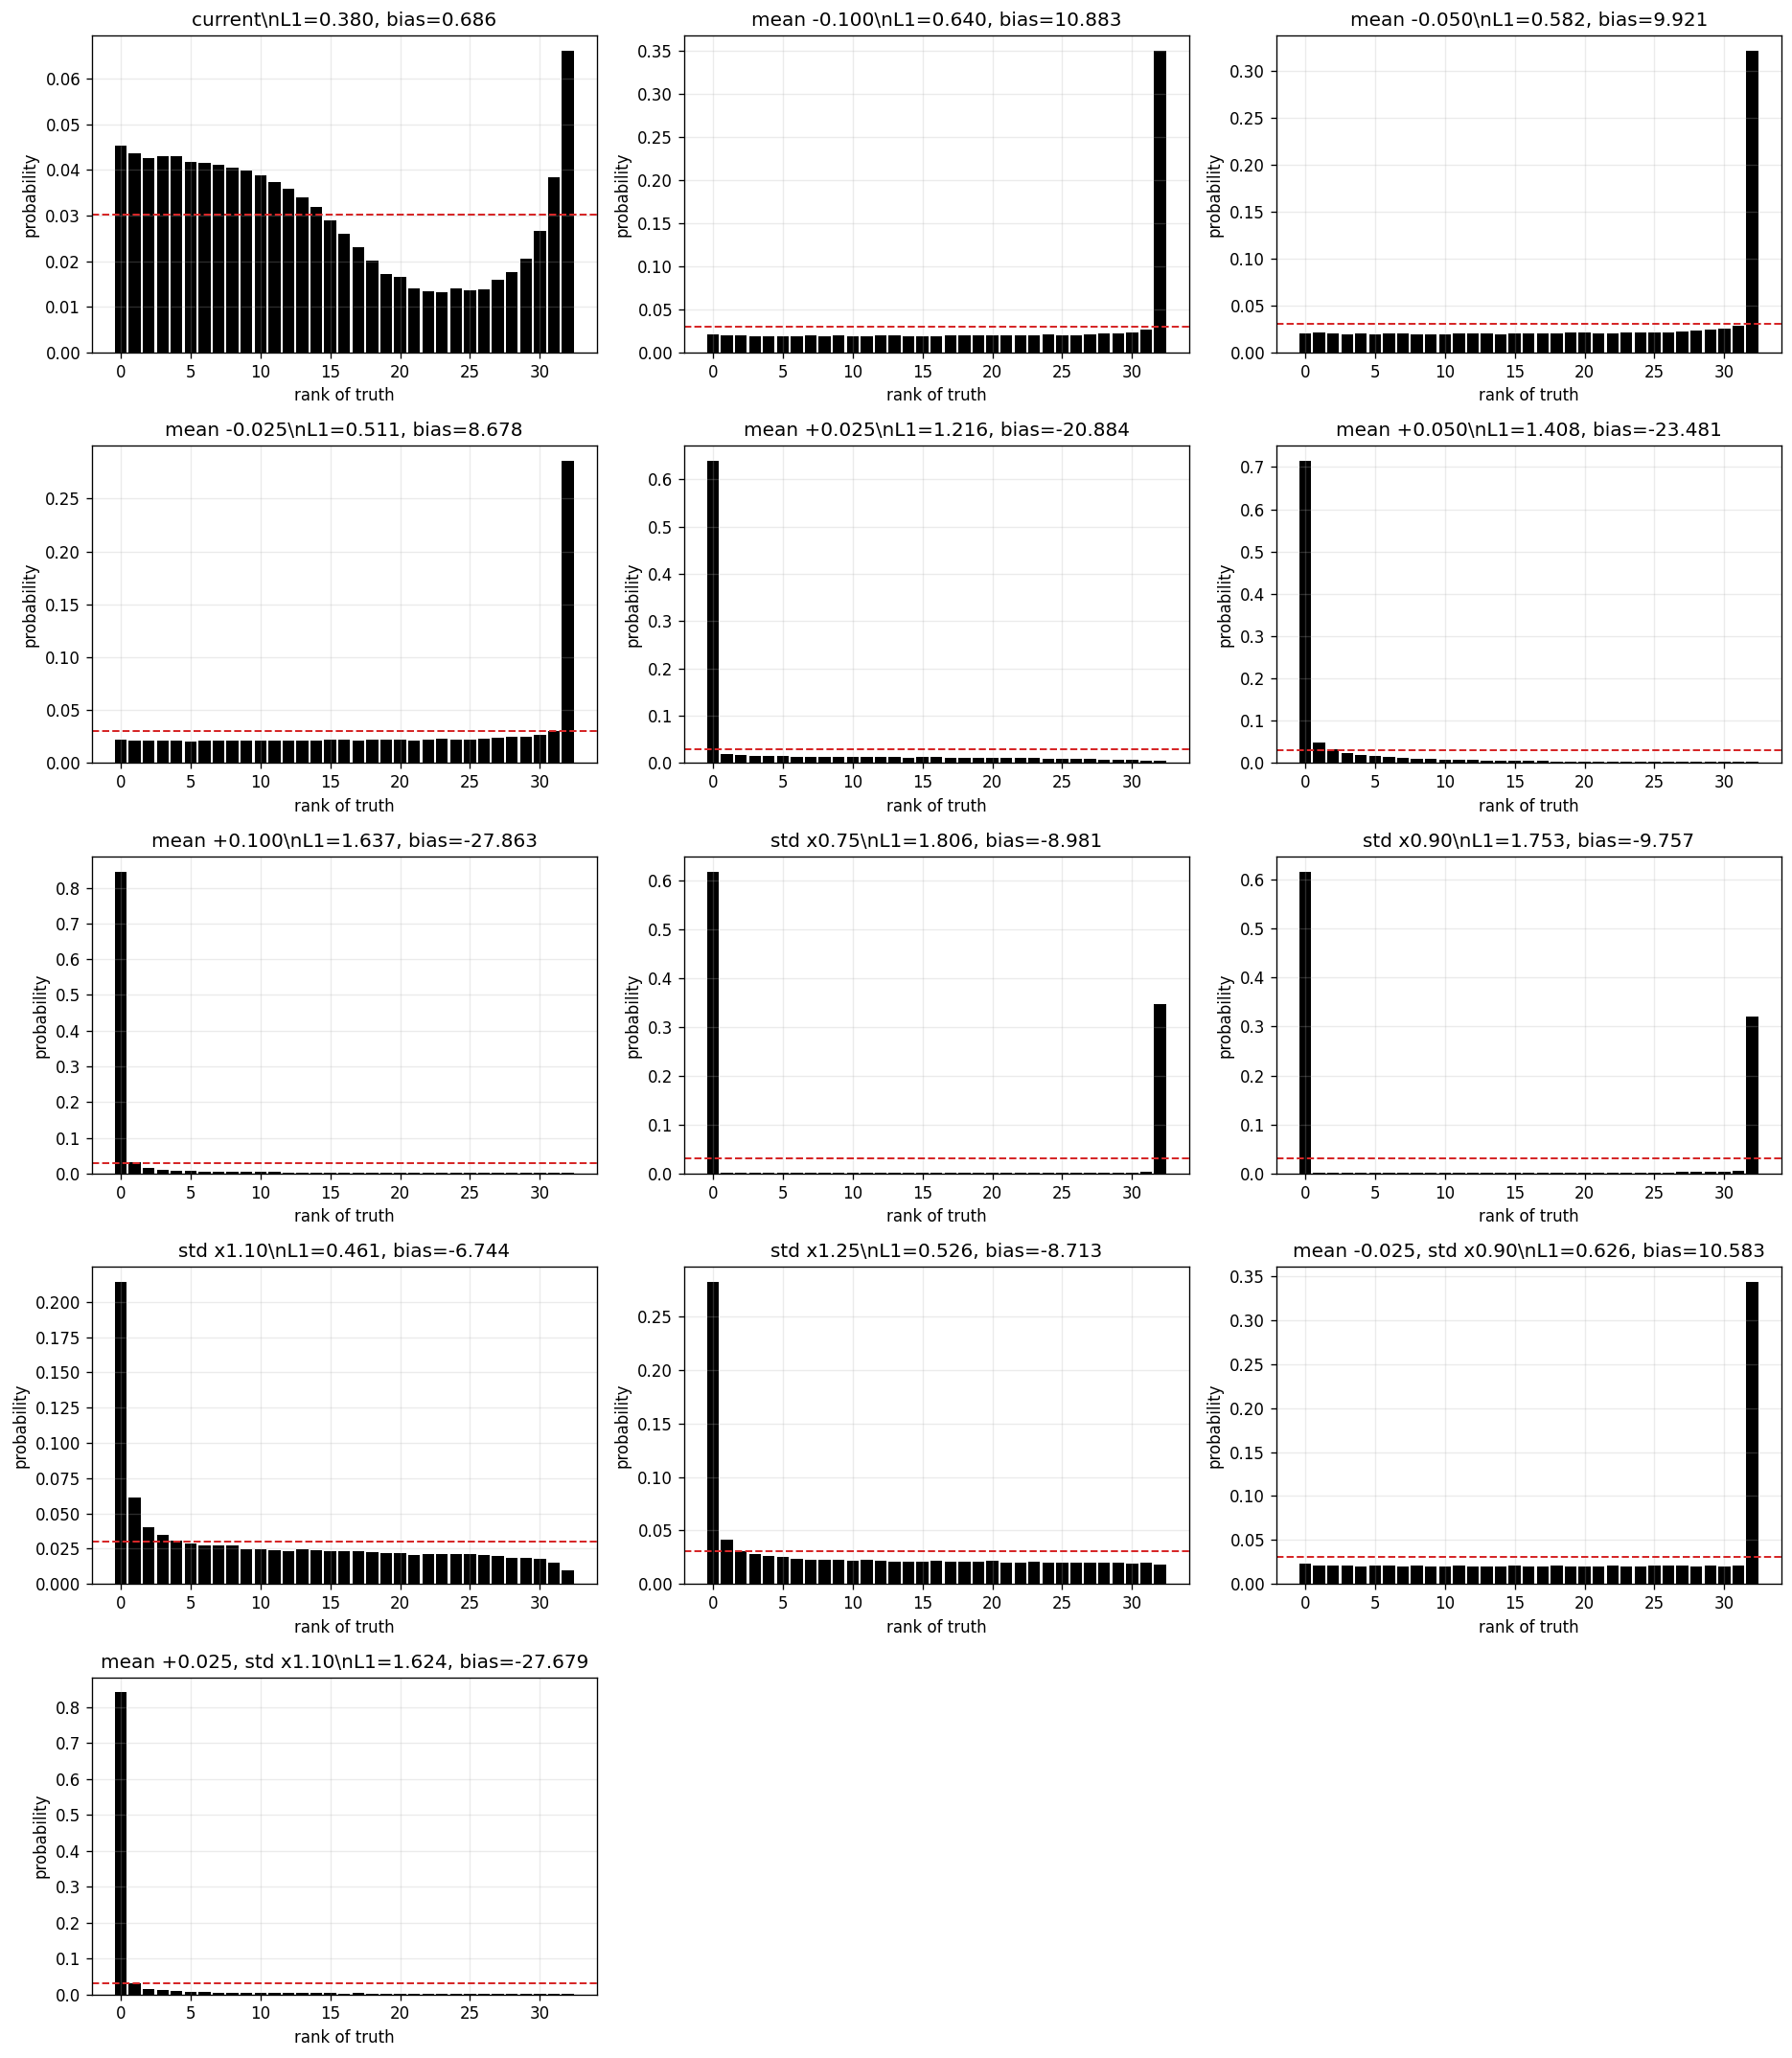

saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/plots/sic_mean_std_sweep/sic_rank_histogram_counts_by_mean_std.npz


In [6]:
def candidate_rank_counts_for_archive(corrected_sub, truth_sub, rank_mask, seed):
    # corrected_sub shape: (K, M, Hs, Ws); truth_sub shape: (Hs, Ws).
    k_count, ensemble_size = corrected_sub.shape[:2]
    less = np.sum(corrected_sub < truth_sub[None, None, :, :], axis=1)
    ties = np.sum(corrected_sub == truth_sub[None, None, :, :], axis=1)

    rng = np.random.default_rng(seed)
    ranks = less + rng.integers(0, ties + 1)
    ranks = ranks[:, rank_mask]

    out = np.zeros((k_count, ensemble_size + 1), dtype=np.int64)
    for k in range(k_count):
        out[k] = np.bincount(ranks[k].reshape(-1).astype(np.int64), minlength=ensemble_size + 1)
    return out


rank_counts = None
metric_sums = {label: {"rmse_sum": 0.0, "bias_sum": 0.0, "mae_sum": 0.0, "n": 0} for label in CANDIDATE_LABELS}

t0 = time.perf_counter()
for archive_i, path in enumerate(tensor_paths):
    with np.load(path, allow_pickle=False) as z:
        ensemble_sic = z["ensemble"][:, CHANNEL]
        truth_sic = z["truth"][CHANNEL].astype(np.float64)
        observed_mask = z["mask"]
        combo_seed = scalar_int(z, "combo_seed", archive_i)

    valid_mask = load_valid_mask(truth_sic.shape)
    eval_mask = make_eval_mask(observed_mask, valid_mask, EVAL_REGION)

    corrected = apply_all_candidate_stats(ensemble_sic, valid_mask)
    corrected_sub = corrected[:, :, ::RANK_STRIDE, ::RANK_STRIDE]
    truth_sub = truth_sic[::RANK_STRIDE, ::RANK_STRIDE]
    rank_mask = eval_mask[::RANK_STRIDE, ::RANK_STRIDE]

    counts = candidate_rank_counts_for_archive(corrected_sub, truth_sub, rank_mask, seed=combo_seed + CHANNEL)
    rank_counts = counts.copy() if rank_counts is None else rank_counts + counts

    means = corrected.mean(axis=1)  # K, H, W
    diff = means - truth_sic[None, :, :]
    for k, label in enumerate(CANDIDATE_LABELS):
        if np.any(eval_mask):
            metric_sums[label]["rmse_sum"] += float(np.sqrt(np.mean(diff[k][eval_mask] ** 2)))
            metric_sums[label]["bias_sum"] += float(np.mean(diff[k][eval_mask]))
            metric_sums[label]["mae_sum"] += float(np.mean(np.abs(diff[k][eval_mask])))
            metric_sums[label]["n"] += 1

print(f"rank histograms computed for {len(tensor_paths)} archives in {time.perf_counter() - t0:.1f} sec")

rank_rows = []
for k, label in enumerate(CANDIDATE_LABELS):
    scores = rank_scores_from_counts(rank_counts[k])
    n_metric = max(1, metric_sums[label]["n"])
    rank_rows.append({
        "label": label,
        "candidate_mean": float(CANDIDATE_MEANS[k]),
        "candidate_std": float(CANDIDATE_STDS[k]),
        **scores,
        "rmse_mean": metric_sums[label]["rmse_sum"] / n_metric,
        "bias_mean": metric_sums[label]["bias_sum"] / n_metric,
        "mae_mean": metric_sums[label]["mae_sum"] / n_metric,
    })

if pd is not None:
    rank_table = pd.DataFrame(rank_rows).sort_values(["l1_flat", "rmse_mean"])
    display(rank_table)
else:
    rank_table = sorted(rank_rows, key=lambda r: (r["l1_flat"], r["rmse_mean"]))
    display(rank_table)

ncols = 3
nrows = int(math.ceil(len(CANDIDATE_LABELS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), squeeze=False)

for ax, k, label in zip(axes.ravel(), range(len(CANDIDATE_LABELS)), CANDIDATE_LABELS):
    counts = rank_counts[k].astype(np.float64)
    probs = counts / max(1.0, counts.sum())
    expected = 1.0 / len(probs)
    scores = rank_scores_from_counts(counts)

    ax.bar(np.arange(len(probs)), probs, color="black", width=0.85)
    ax.axhline(expected, color="tab:red", linestyle="--", linewidth=1.2)
    ax.set_title(
        f"{label}\\n"
        f"L1={scores['l1_flat']:.3f}, bias={scores['right_minus_left_edges_in_flat_units']:.3f}"
    )
    ax.set_xlabel("rank of truth")
    ax.set_ylabel("probability")

for ax in axes.ravel()[len(CANDIDATE_LABELS):]:
    ax.axis("off")

plt.tight_layout()
out_path = SWEEP_PLOTS_DIR / "sic_rank_histograms_by_mean_std.png"
fig.savefig(out_path, dpi=160)
print("saved:", out_path)
plt.show()

counts_path = SWEEP_PLOTS_DIR / "sic_rank_histogram_counts_by_mean_std.npz"
np.savez_compressed(counts_path, **{safe_name(label): rank_counts[k] for k, label in enumerate(CANDIDATE_LABELS)})
print("saved:", counts_path)


## 6. Best Candidate Detail

This cell redraws the best candidate rank histogram as a standalone figure.


best candidate:


{'label': 'current',
 'candidate_mean': 0.1158,
 'candidate_std': 0.3008,
 'total_ranks': 128380,
 'l1_flat': 0.37972968507319654,
 'edge_ratio_vs_flat': 1.8398309705561615,
 'center_ratio_vs_flat': 0.8562548683595577,
 'right_minus_left_edges_in_flat_units': 0.6855507088331516,
 'chi2_like_not_independent': 23892.55547593083,
 'rmse_mean': 0.08765177916917648,
 'bias_mean': -0.005334575422702409,
 'mae_mean': 0.031097233348688004}

saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_swath_30days_x32_r4_saved/plots/sic_mean_std_sweep/sic_rank_histogram_best__current.png


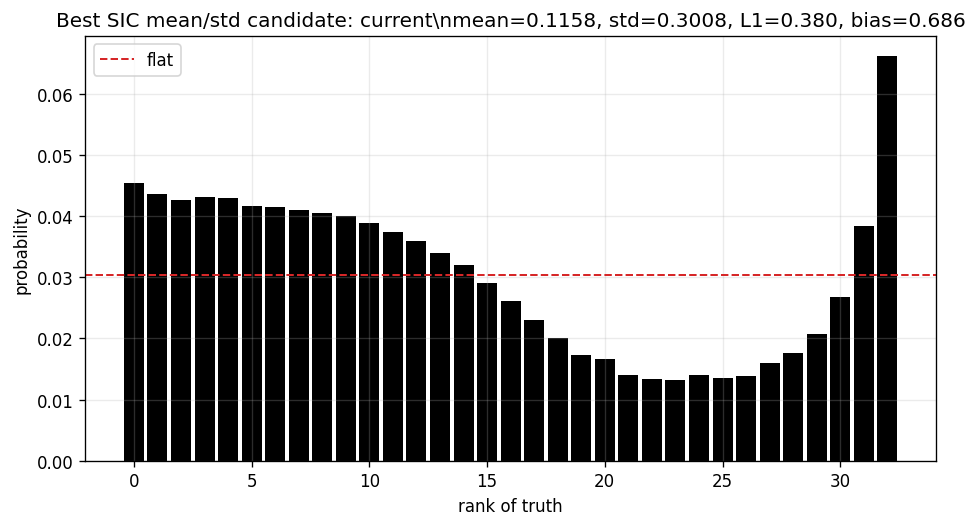

In [7]:
if pd is not None:
    best = rank_table.iloc[0].to_dict()
else:
    best = rank_table[0]

best_label = best["label"]
best_k = CANDIDATE_LABELS.index(best_label)
counts = rank_counts[best_k].astype(np.float64)
probs = counts / max(1.0, counts.sum())
expected = 1.0 / len(probs)

print("best candidate:")
display(best)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(np.arange(len(probs)), probs, color="black", width=0.85)
ax.axhline(expected, color="tab:red", linestyle="--", linewidth=1.2, label="flat")
ax.set_title(
    f"Best SIC mean/std candidate: {best_label}\\n"
    f"mean={best['candidate_mean']:.6g}, std={best['candidate_std']:.6g}, "
    f"L1={best['l1_flat']:.3f}, bias={best['right_minus_left_edges_in_flat_units']:.3f}"
)
ax.set_xlabel("rank of truth")
ax.set_ylabel("probability")
ax.legend()
fig.tight_layout()

out_path = SWEEP_PLOTS_DIR / f"sic_rank_histogram_best__{safe_name(best_label)}.png"
fig.savefig(out_path, dpi=180)
print("saved:", out_path)
plt.show()
